# Fake Job Posting Detection using Machine Learning

## Internship Final Project

Developed By:
Krishna Kailas Paralkar

### Technology Used:
- Python
- Machine Learning
- TF-IDF
- Logistic Regression
- Naive Bayes
- Random Forest
- SVM
- XGBoost
- Streamlit

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("../data/fake_job_postings.csv")
print(df.shape)
print(df.columns)
df.head()

(17880, 18)
Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df = df.drop(columns=[
    "job_id", "telecommuting", "has_company_logo", "has_questions","salary_range", "benefits", "department"
])

In [ ]:
df = df.dropna(subset= ['description', 'requirements'])

In [ ]:
df['text'] = df['title'] + " " + df['description'] + " " + df['requirements']

In [ ]:
df['text'].head()

0    Marketing Intern Food52, a fast-growing, James...
1    Customer Service - Cloud Video Production Orga...
2    Commissioning Machinery Assistant (CMA) Our cl...
3    Account Executive - Washington DC THE COMPANY:...
4    Bill Review Manager JOB TITLE: Itemization Rev...
Name: text, dtype: str

In [ ]:
import nltk

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to C:\Users\Paras
[nltk_data]     Mahadik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Paras
[nltk_data]     Mahadik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Paras
[nltk_data]     Mahadik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    words = word_tokenize(text)  
    words = [word for word in words if word not in stop_words] 
    return " ".join(words)

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df[['text', 'clean_text']].head()

,text,clean_text
0,"Marketing Intern Food52, a fast-growing, James...",marketing intern food52 fastgrowing james bear...
1,Customer Service - Cloud Video Production Orga...,customer service cloud video production organi...
2,Commissioning Machinery Assistant (CMA) Our cl...,commissioning machinery assistant cma client l...
3,Account Executive - Washington DC THE COMPANY:...,account executive washington dc company esri –...
4,Bill Review Manager JOB TITLE: Itemization Rev...,bill review manager job title itemization revi...


In [ ]:
X = df['text']

In [ ]:
y = df['fraudulent']

In [ ]:
print(df["fraudulent"].value_counts())

fraudulent
0    14472
1      712
Name: count, dtype: int64


In [ ]:
X_raw = df['clean_text'].astype(str).fillna('').reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
text_data = df['text']
labels = df['fraudulent']
X_raw = df['clean_text'].astype(str).fillna('').reset_index(drop=True)
X_train_text, X_test_text, y_train, y_test = train_test_split(X_raw,labels, test_size= 0.2, random_state=42)
X_test_raw = X_test_text.reset_index(drop=True)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)
X = tfidf_vectorizer.fit_transform(df['clean_text'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
                                                

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(12147, 5000) (3037, 5000)
(12147,) (3037,)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9611458676325321

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      2876
           1       0.98      0.27      0.43       161

    accuracy                           0.96      3037
   macro avg       0.97      0.64      0.70      3037
weighted avg       0.96      0.96      0.95      3037



In [ ]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

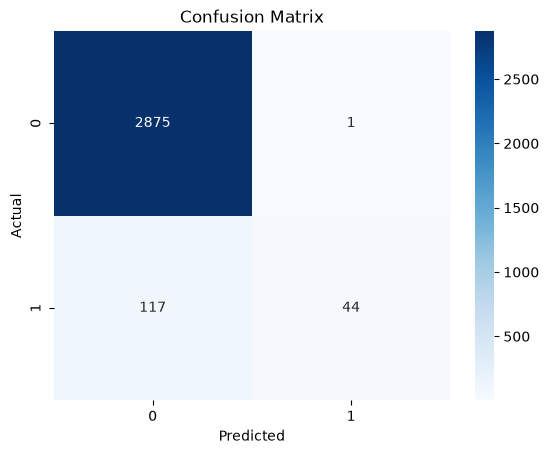

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("../visuals/confusion_matrix.png")
plt.show()

In [ ]:
from lime.lime_text import LimeTextExplainer
import numpy as np

In [ ]:
explainer = LimeTextExplainer(class_names=['Real', 'Fake'])

In [ ]:
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    return model.predict_proba(tfidf_vectorizer.transform(texts))

In [ ]:
sample_index = 0
sample_text = X_test_text.iloc[1]
print("Text:\n", sample_text)

Text:
 director content marketing director content marketing passionate experienced marketer lead content marketing efforts vision growth person work ensure content fresh full practical advice always engaging customers potential users help identify content goals strategies work rest marketingcontent team achieve goals drive awareness ultimately achieve sales product successful candidate must solid understanding inbound marketing lead generation well expertise creating engaging content highlytechnical audience ideal candidate seen expert b2b marketing space loves write – mean really loves write person able articulate business compelling way much marketer content editorhelp maintain master coschedule editorial calendar continually strengthen approach content marketingcraft newsletters social media content contribute coschedule blogcoordinate writing content contributors including freelancers guest authors staff writersexplore editorial partnerships content distribution options content ou

In [ ]:
sample_index = 1
sample_text = X_test_text.iloc[2]
print("Text:\n", sample_text)

Text:
 wf17 9lu customer service apprenticeship fantastic opportunity someone wanting start career customer service first 12 months work towards level 2 customer service nvq kept permanent positionyou working distribution company role involveproviding high level customer service conversationworking alongside marketing team assist daily tasksthese tasks include adding new productsinputting information contacting service providersideal candidates computer literate excellent communication skillsif honest hard working send cv email0e92123d11734167533acc44a2e74ffac0b6f56d256225a89769e0641a3d1aee government funding available 1618 year olds job apprenticeship


In [ ]:
sample_index = 2
sample_text = X_test_text.iloc[3]
print("Text:\n", sample_text)

Text:
 video journalist dari pashto language video journalist shall least five years current experience video journalist shall perform combination services respect acquiring news video content including researching photographing lighting editing producing video journalist shall provide video photography editing services go beyond standard camera operation video journalist shall well versed video photographic styles techniques able tell story pictures video journalist shall required serve producer television news feature stories video journalist shall required serve video editor script timed video shots natural sound emerges actualities complete suggested visual audio graphic efforts andor perform desktop video editing practical video journalist shall familiar agency ’ best practices guide shall adhere policies video journalist shall properly complete daily tasks daily tasks include limited performing basic functions video assignments fails twice per week preparing video elements assign

In [ ]:
sample_index = 3
sample_text = X_test_text.iloc[0]
print("Text:\n", sample_text)

Text:
 intern businessproducer team aspiring producers business leads looking gain handson experience digital business come support mediamonks business amp producer team hilversum headquarters twenty minutes outside amsterdam search inspired intern eager expand knowledge international business interactive advertising logistics caffeinemediamonks offering opportunity develop client service producer skills well competitive payment cover expenses part biggest creative digital production company planet ’ producing worldclass work top global advertising agencies desired candidate enthusiastic individual passion digital process finishing hbo academic studies ideally dutch firstlanguage confident ability speak read write englishthe internship span five seven months forty hours week potential internship result career us fact tangible testament unadulterated epicness internships many exinterns still part team – first interns join mediamonks occupying key positions company therefore looking some

In [ ]:
sample_index = 4
sample_text = X_test_text.iloc[10]
print("Text:\n", sample_text)

Text:
 food aide cashier brighter choice charter schools seeking motivated qualified candidates join nutrition department either parttime food aide cashier 201415 school yearposition summary parttime food aide cashier work collaboratively nutritional staff prepare serve food cafeteria students teachers operate steam table salad bar main entrée beverage area check temperature quality prepared foods maintain cleanliness sanitation work area equipment may also organize prepare assemble food itemsabout brighter choice charter schoolsthe mission brighter choice charter schools ensure bccs scholars opportunities future success students attending best public schools region three significant components achieving mission exemplary instruction ensures competency mastery reading writing mathematics focus development social behavioral organizational skills necessary future school success education beyond basics includes performing arts visual arts science history food aide cashier job description 

In [ ]:
exp = explainer.explain_instance(sample_text, predict_proba, num_features=10)
# exp.show_in_notebook(text = True)

In [ ]:
exp.save_to_file('../visuals/lime_explanation_sample0.html')

In [ ]:
sample_index = 5
exp = explainer.explain_instance(X_test_raw[sample_index], predict_proba, num_features=10)
# exp.show_in_notebook(text = True)

In [ ]:
sample_index = 99
exp = explainer.explain_instance(X_test_raw[sample_index], predict_proba, num_features=10)
# exp.show_in_notebook(text = True)

In [ ]:
exp.save_to_file('../visuals/lime_explanation_sample99_real.html')

In [ ]:
sample_index = 499
exp = explainer.explain_instance(X_test_raw[sample_index], predict_proba, num_features=10)
# exp.show_in_notebook(text = True)

In [ ]:
import shap
from shap.explainers import Linear
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X_sample_raw = X_test_raw[:500]
X_sample_vec = tfidf_vectorizer.transform(X_sample_raw)

In [ ]:
X_sample_vec = X_test[:500]

In [ ]:
X_sample = X_test_raw[:500]

In [ ]:
def shap_predict(texts):
    X_vec = tfidf_vectorizer.transform(texts)
    return model.predict_proba(X_vec)

In [ ]:
explainer = Linear(model, X_sample_vec)

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


In [ ]:
shap_values = explainer(X_sample_vec)

In [ ]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


In [ ]:
print(shap_values)

.values =
array([[ 0.00014433, -0.0013542 , -0.00010029, ..., -0.        ,
        -0.        , -0.        ],
       [ 0.00014433, -0.0013542 , -0.00010029, ..., -0.        ,
        -0.        , -0.        ],
       [ 0.00014433, -0.0013542 , -0.00010029, ..., -0.        ,
        -0.        , -0.        ],
       ...,
       [ 0.00014433, -0.0013542 , -0.00010029, ..., -0.        ,
        -0.        , -0.        ],
       [ 0.00014433, -0.0013542 , -0.00010029, ..., -0.        ,
        -0.        , -0.        ],
       [ 0.00014433, -0.0013542 , -0.00010029, ..., -0.        ,
        -0.        , -0.        ]], shape=(500, 5000))

.base_values =
array([-3.81884347, -3.81884347, -3.81884347, -3.81884347, -3.81884347,
       -3.81884347, -3.81884347, -3.81884347, -3.81884347, -3.81884347,
       -3.81884347, -3.81884347, -3.81884347, -3.81884347, -3.81884347,
       -3.81884347, -3.81884347, -3.81884347, -3.81884347, -3.81884347,
       -3.81884347, -3.81884347, -3.81884347, -3.81884

In [ ]:
shap_values.values.shape

(500, 5000)

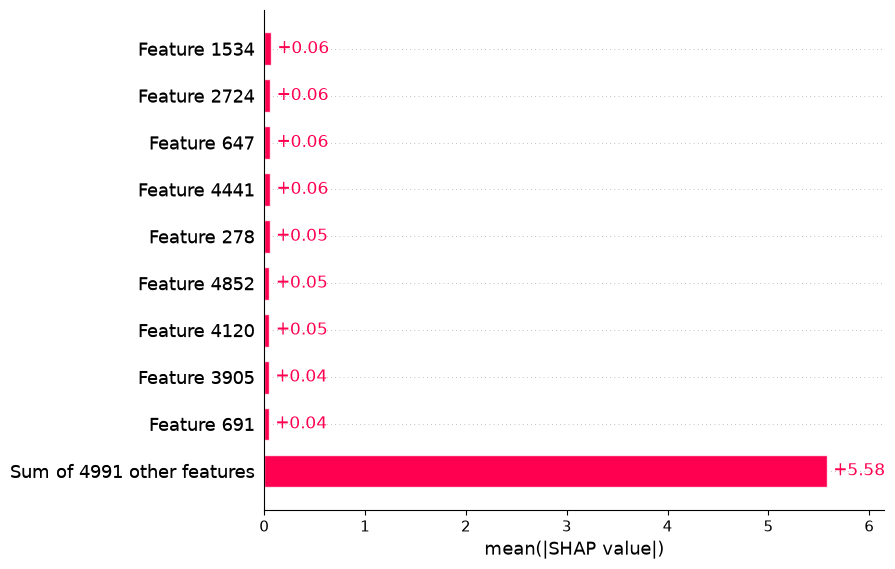

In [ ]:
shap.plots.bar(shap_values)

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


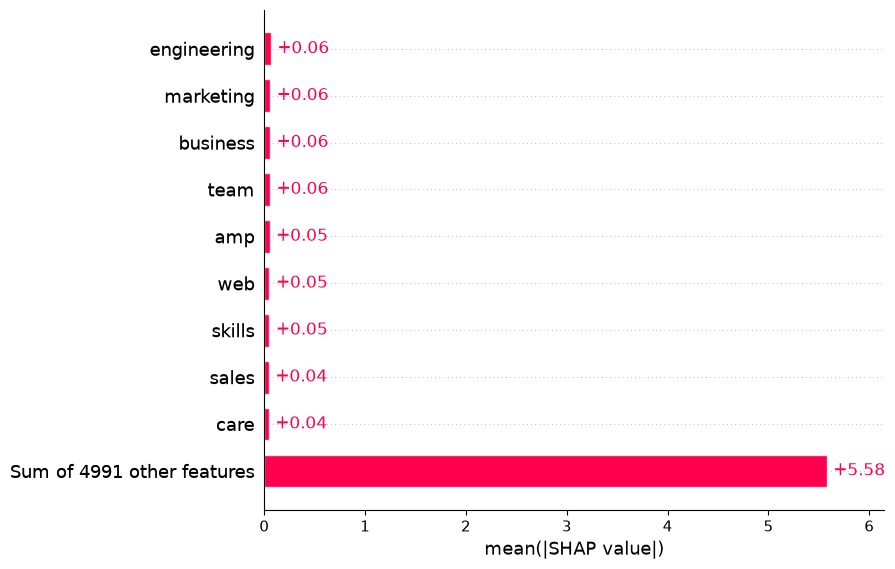

In [ ]:
explainer = shap.explainers.Linear(model, X_sample_vec, feature_names=feature_names)
shap_values = explainer(X_sample_vec)
shap.plots.bar(shap_values)

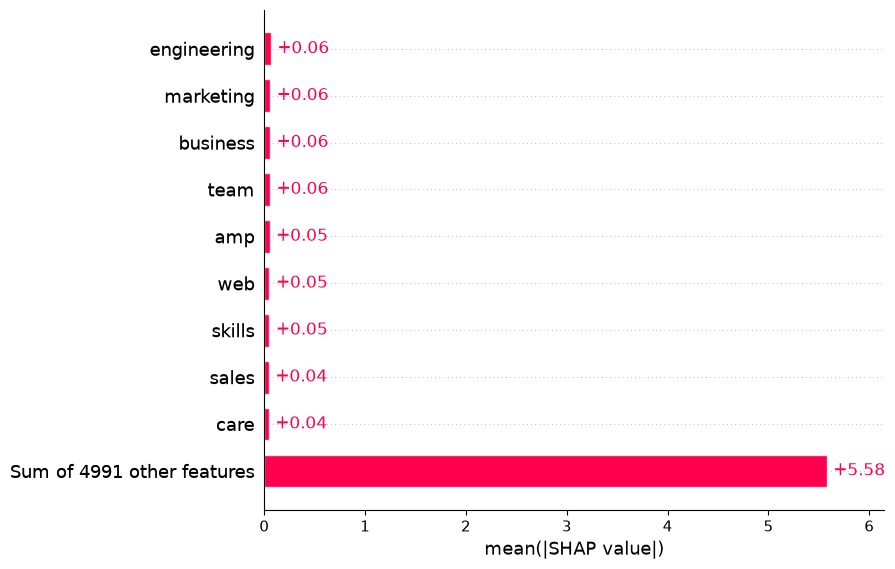

In [ ]:
plt.figure()
shap.plots.bar(shap_values, show = False)
plt.savefig('../visuals/shap_summary_plot.png', bbox_inches= 'tight')

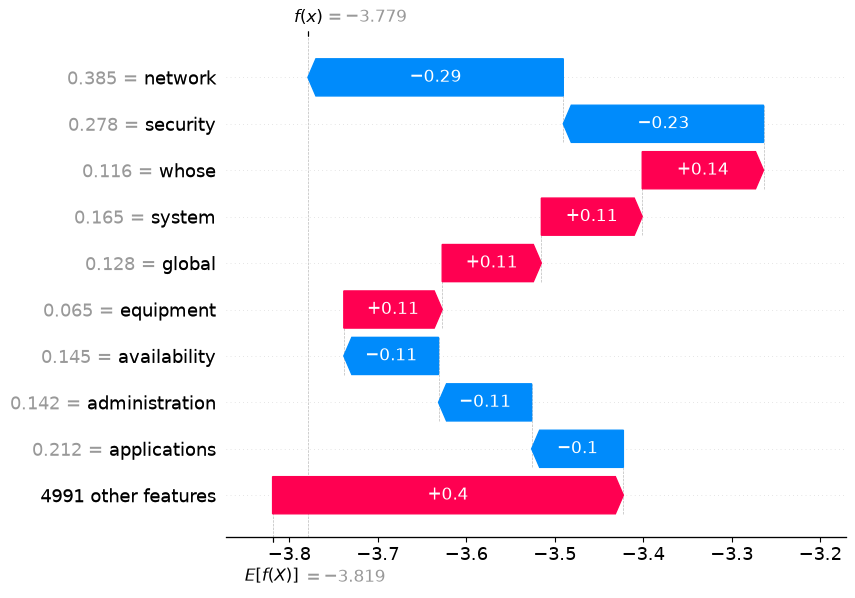

In [ ]:
shap.plots.waterfall(shap_values[456])

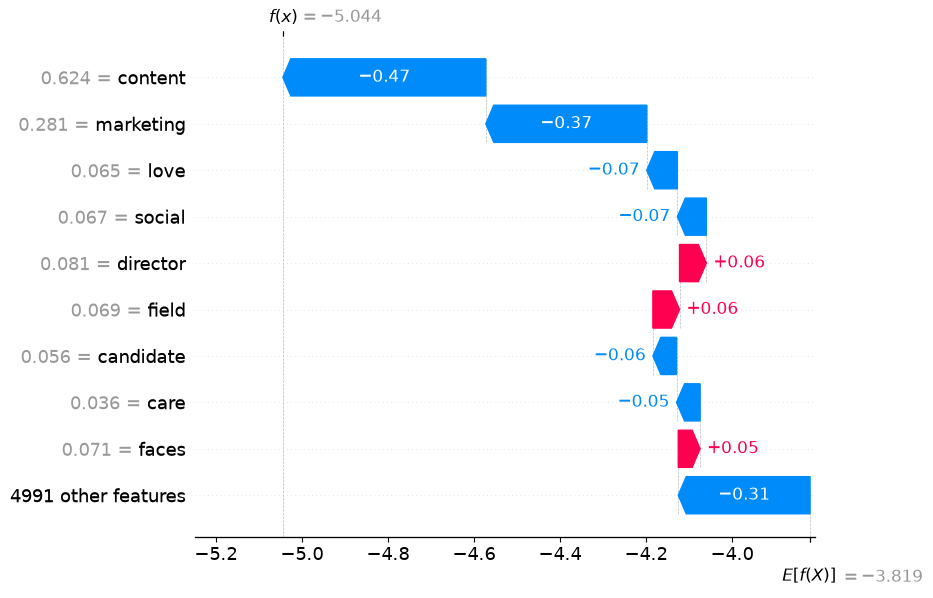

In [ ]:
shap.plots.waterfall(shap_values[1])

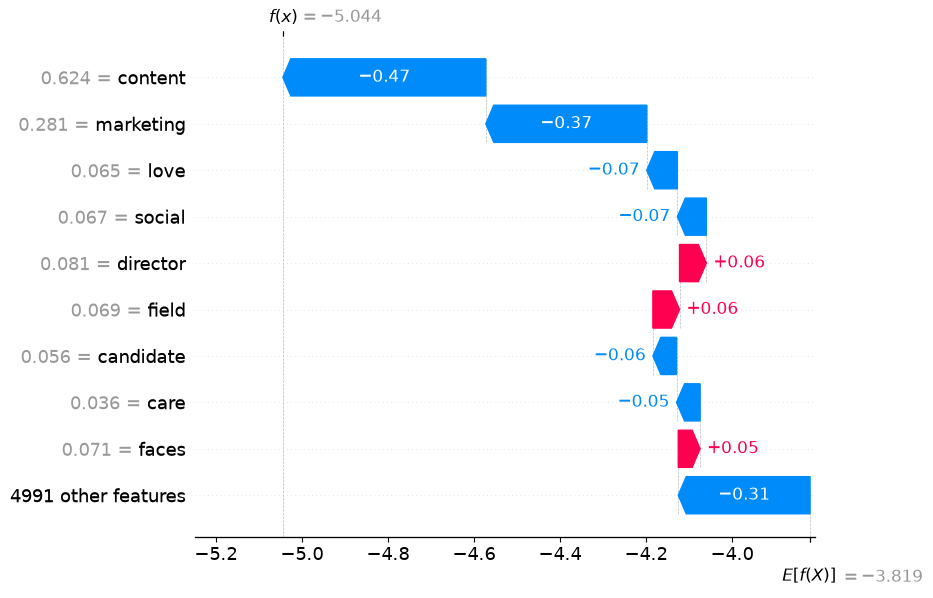

In [ ]:
plt.figure()
shap.plots.waterfall(shap_values[1], show = False)
plt.savefig('../visuals/shap_waterfall_sample1.png', bbox_inches= 'tight')

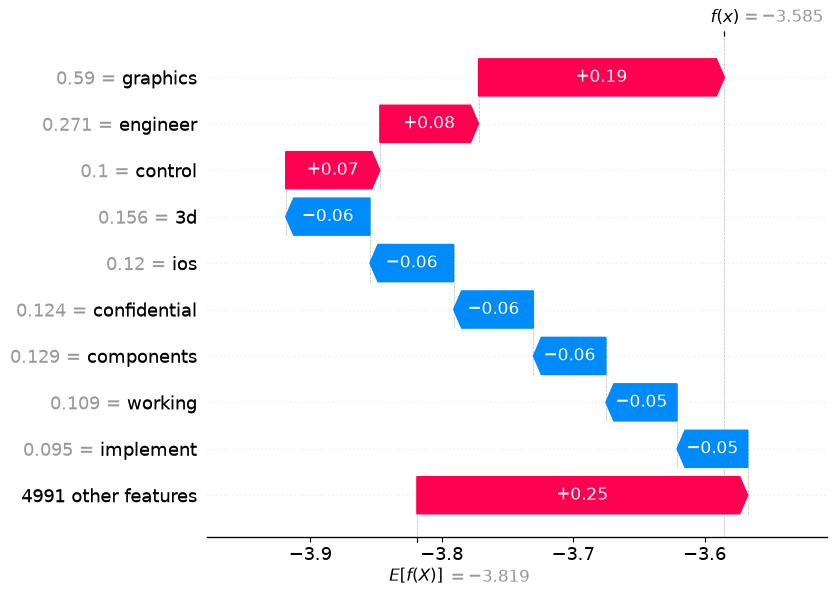

In [ ]:
shap.plots.waterfall(shap_values[6])

In [ ]:
plt.figure()
shap.plots.waterfall(shap_values[6], show = False)
plt.savefig('../visuals/shap_waterfall_sample2.png', bbox_inches= 'tight')

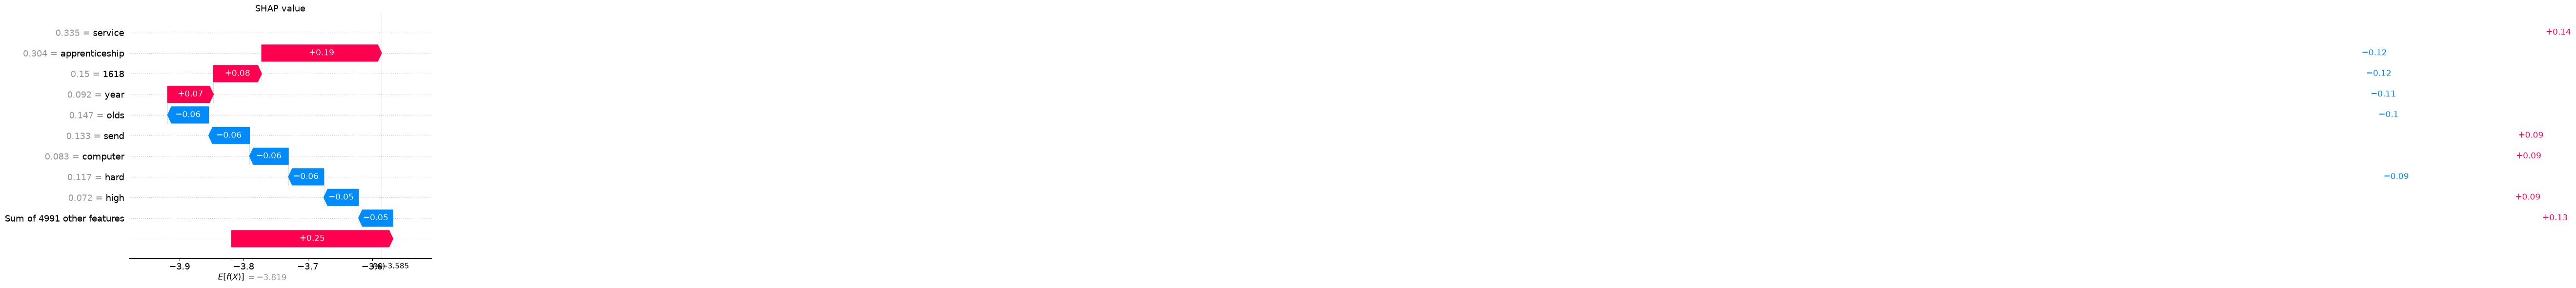

In [ ]:
shap.plots.bar(shap_values[2])

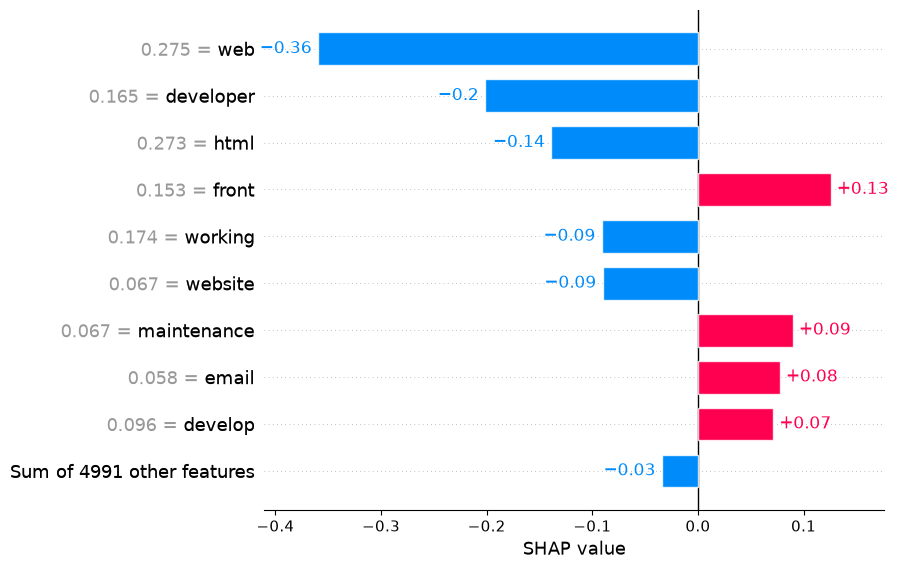

In [ ]:
shap.plots.bar(shap_values[499])

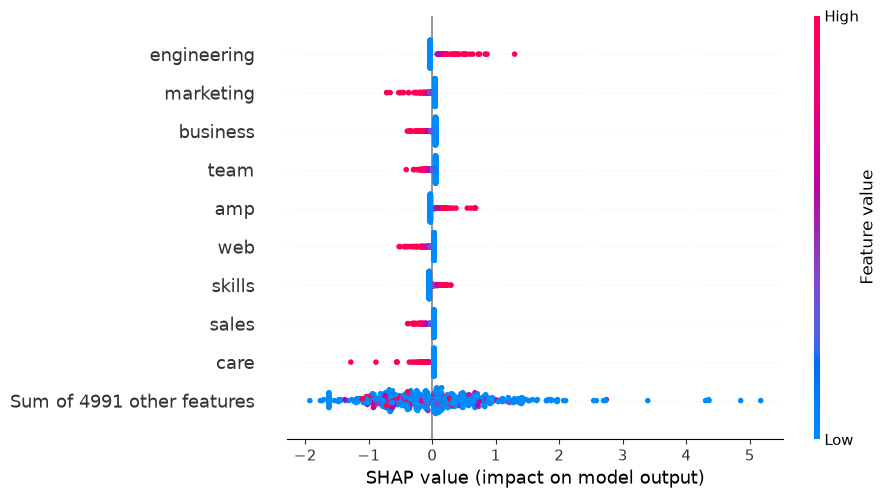

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
plt.figure()
shap.plots.beeswarm(shap_values, show = False)
plt.savefig('../visuals/shap_beeswarm_plot.png', bbox_inches= 'tight')

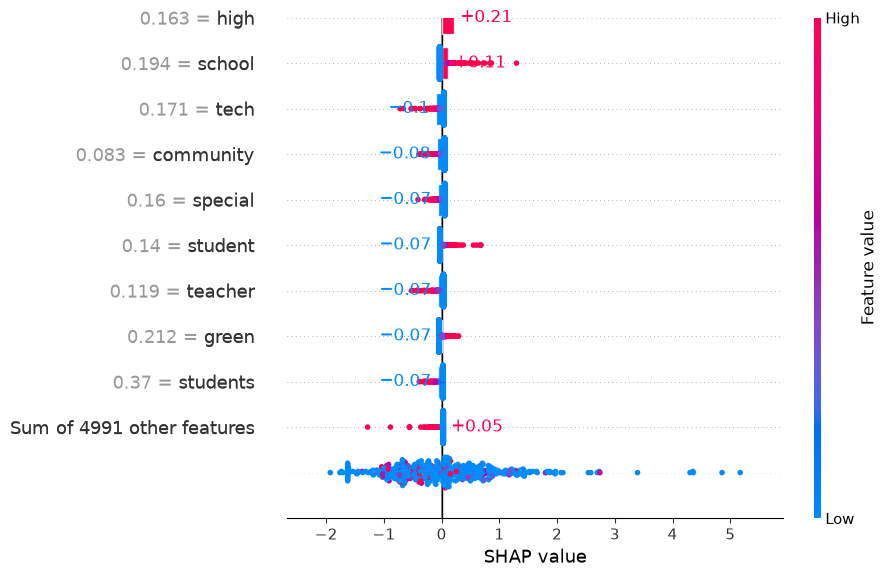

In [ ]:
shap.plots.bar(shap_values[479])

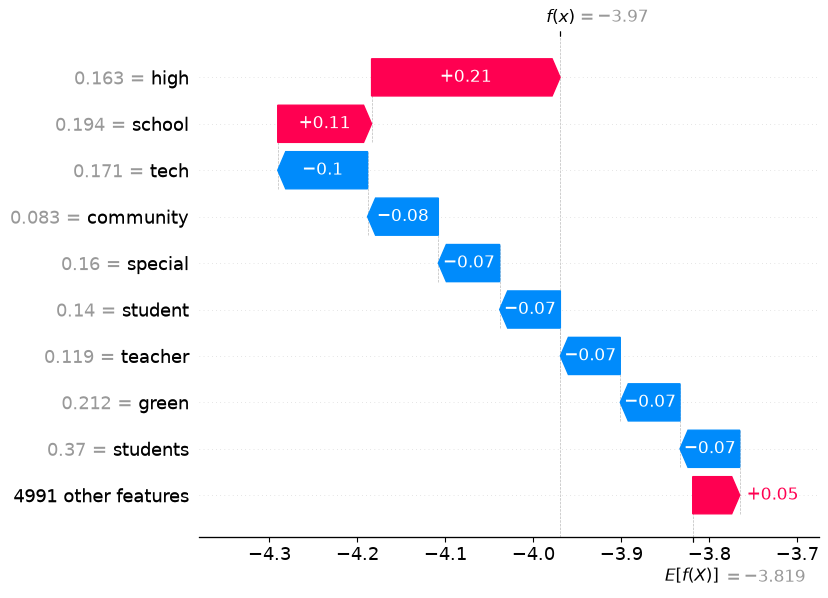

In [ ]:
 shap.plots.waterfall(shap_values[479])

In [ ]:
# Model Comparison and Evaluation

In [ ]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost" : XGBClassifier(use_label_encoder=False, eval_metric = 'logloss'),
    "SVM" : SVC(kernel= 'linear'),
    "Naive Bayes" : MultinomialNB()
}

In [2]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
    "Model": name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score":f1_score(y_test , y_pred),
    })
    

NameError: name 'models' is not defined

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending = False)
results_df.reset_index(drop= True, inplace = True)

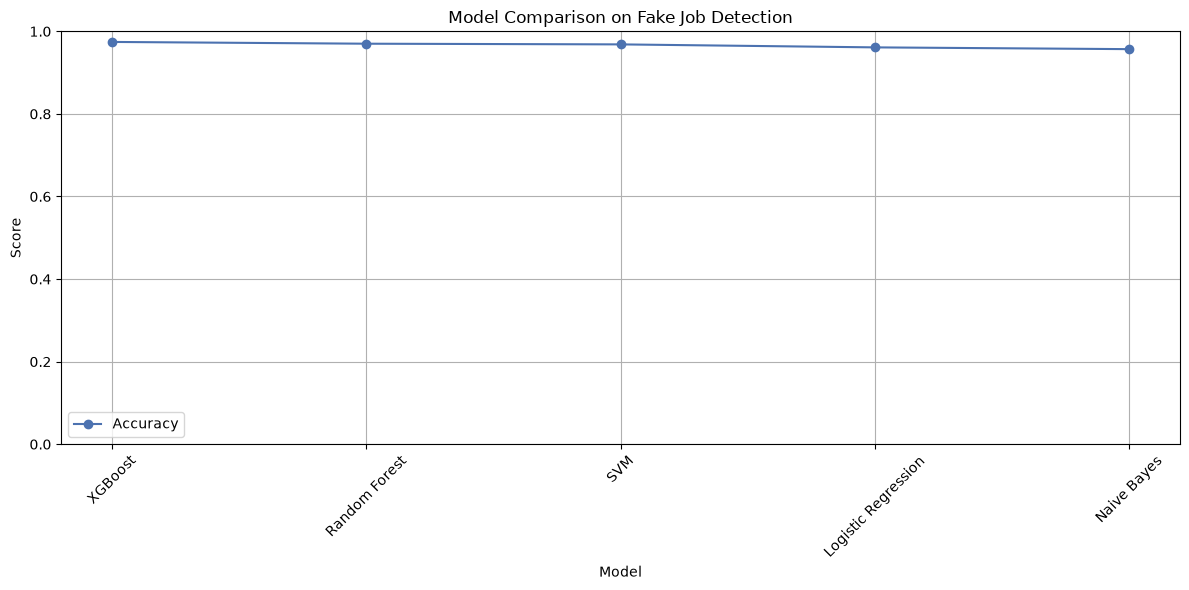

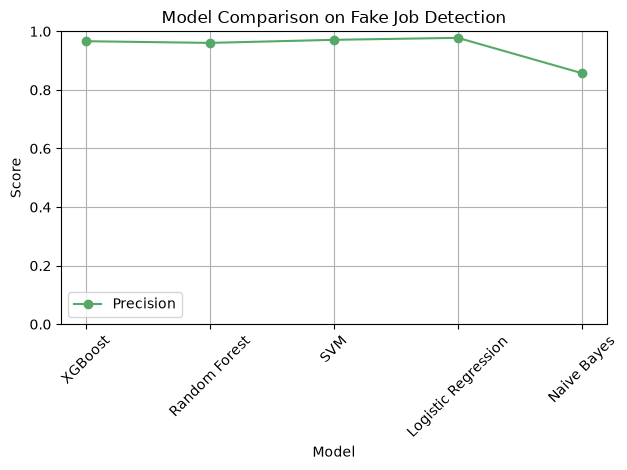

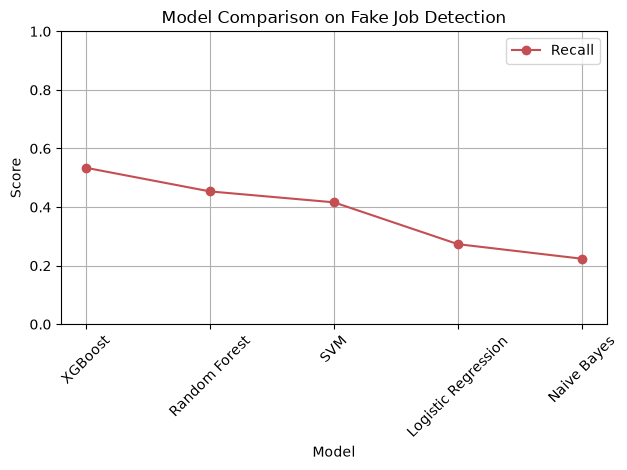

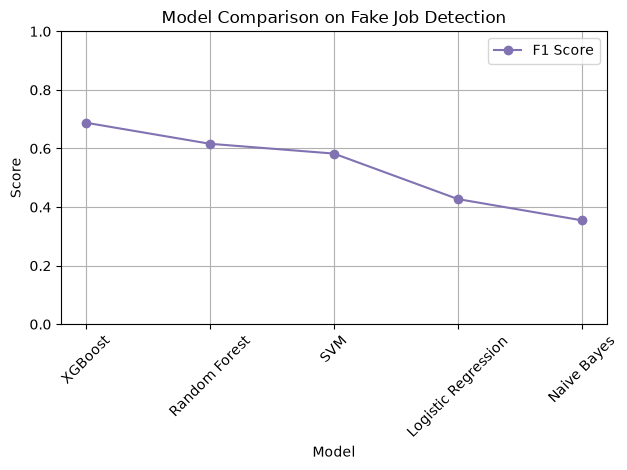

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision","Recall", "F1 Score"]
colors = ["#4c72b0","#55a868", "#c44e52", "#8172b2"]

plt.figure(figsize= (12,6))
for i, metric in enumerate(metrics):
    plt.plot(results_df["Model"], results_df[metric], marker ='o', label = metric , color=colors[i])

    plt.title("Model Comparison on Fake Job Detection")
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.ylim(0,1)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../visuals/model_comparison_multimetric.png', dpi=300)
    plt.show()

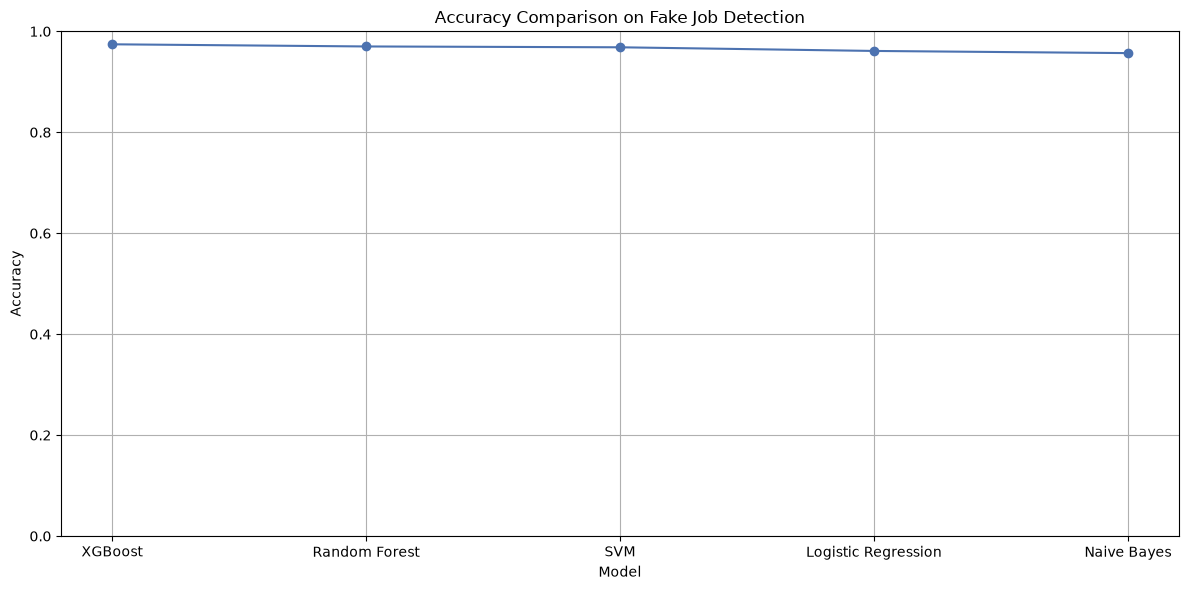

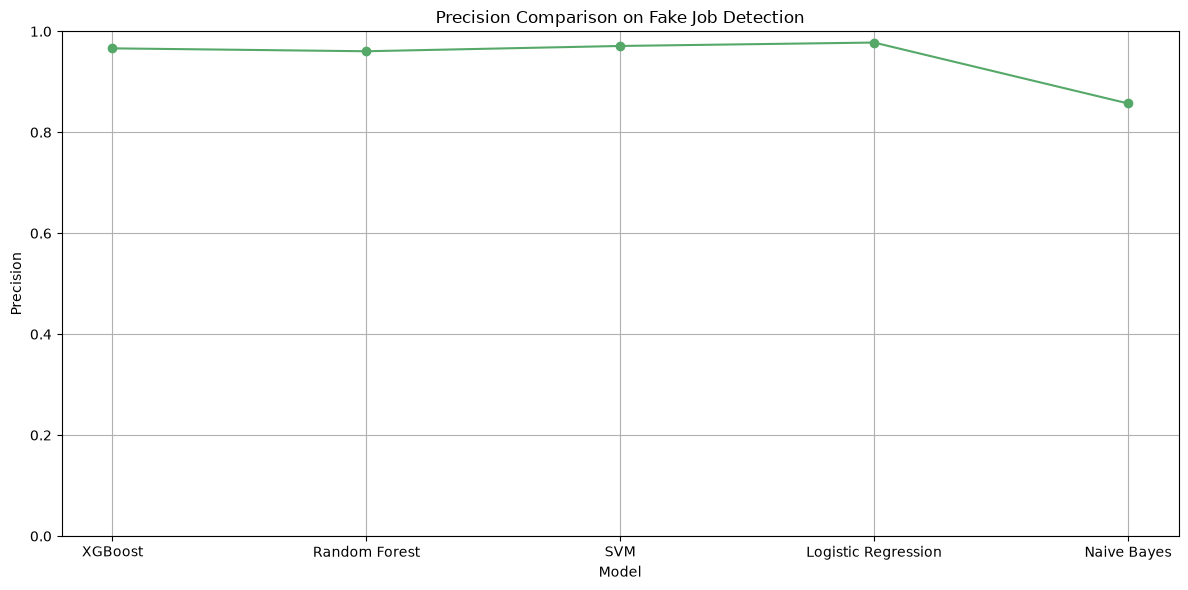

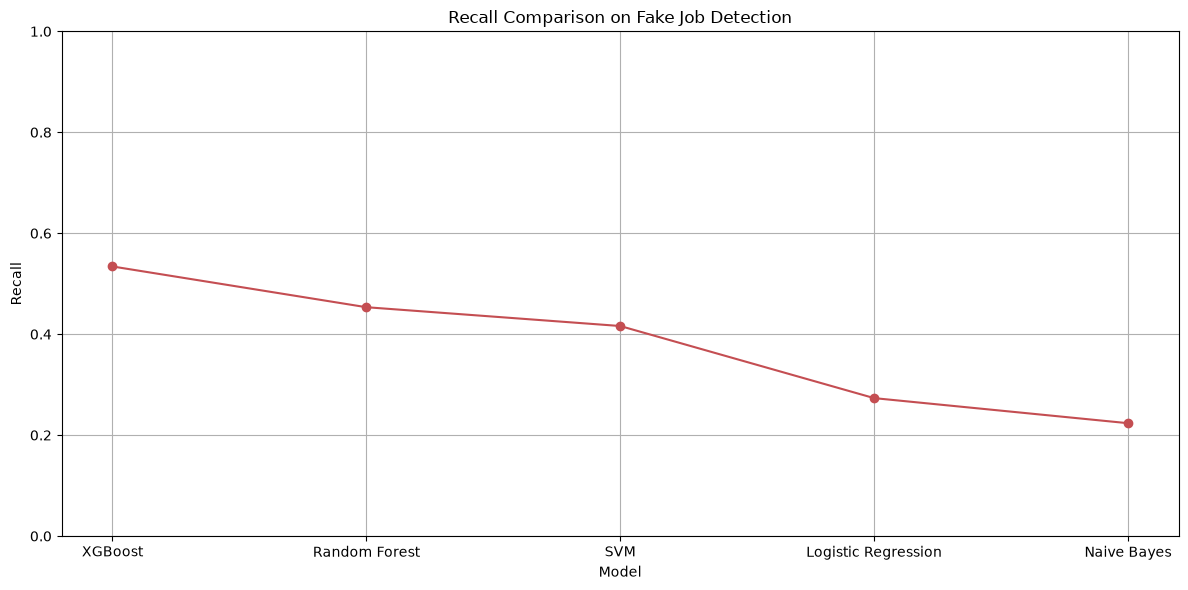

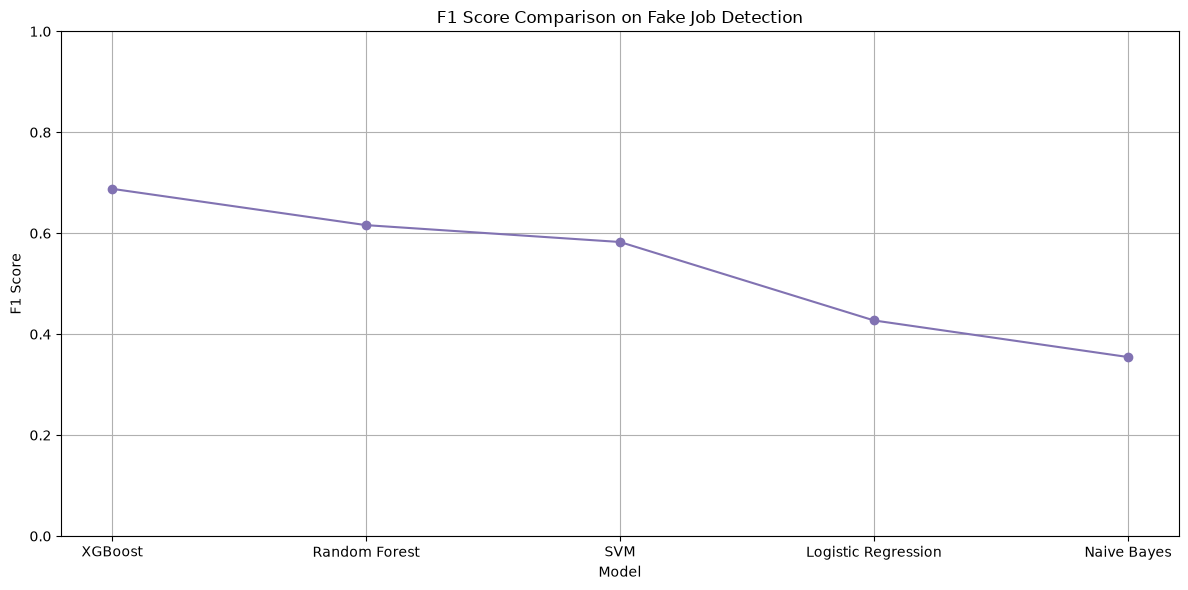

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]

for i, metric in enumerate(metrics):
    plt.figure(figsize=(12, 6))
    plt.plot(results_df["Model"], results_df[metric], marker='o', color=colors[i])
    plt.title(f"{metric} Comparison on Fake Job Detection")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    

    plt.savefig(f"../visuals/model_comparison_{metric.lower().replace(' ', '_')}.png")
    plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
param_grid = {
    'n_estimators': [100, 200],           
    'max_depth': [3, 5, 7],               
    'learning_rate': [0.01, 0.1, 0.2],    
    'subsample': [0.8, 1],                
    'colsample_bytree': [0.8, 1]          
}

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',       
    cv=3,               
    verbose=2,
    n_jobs=-1           
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


C:\Users\Paras Mahadik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [11:00:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exa

In [ ]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1}


In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2876
           1       0.97      0.55      0.70       161

    accuracy                           0.97      3037
   macro avg       0.97      0.77      0.84      3037
weighted avg       0.97      0.97      0.97      3037

Confusion Matrix:

[[2873    3]
 [  73   88]]


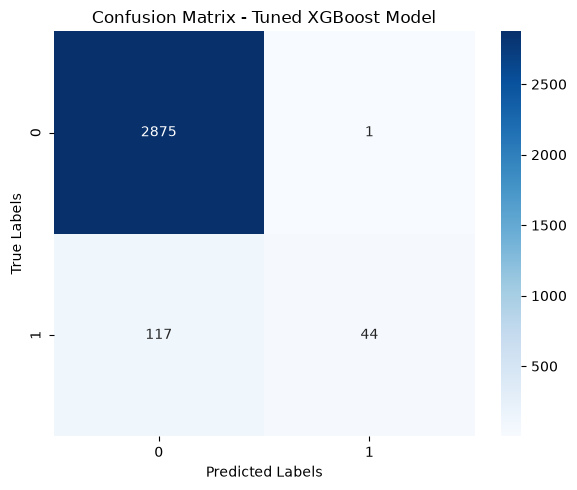

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Tuned XGBoost Model")

plt.tight_layout()
plt.savefig("../visuals/confusion_matrix_tuned_xgb.png", dpi=300)
plt.show()

In [ ]:
import joblib
joblib.dump(best_model, '../model/xgb_final_model.joblib')
joblib.dump(tfidf_vectorizer, '../model/tfidf_vectorizer.joblib')

['../model/tfidf_vectorizer.joblib']

In [ ]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import streamlit as st
import joblib
import numpy as np

model = joblib.load('../model/xgb_final_model.joblib') 
vectorizer = joblib.load('../model/tfidf_vectorizer.joblib') 

st.set_page_config(page_title="Fake Job Detection", layout="centered")

st.title("🕵️‍♂️ Fake Job Posting Detector")
st.write("Enter job posting details and find out whether it's real or fake!")

title = st.text_input("Job Title")
description = st.text_area("Job Description")
requirements = st.text_area("Job Requirements")

if st.button("Predict"):
    if title.strip() == "" or description.strip() == "" or requirements.strip() == "":
        st.warning("Please fill in all the fields.")
    else:
        text = title + " " + description + " " + requirements
        text_vector = vectorizer.transform([text])
        prediction = model.predict(text_vector)[0]
        probability = model.predict_proba(text_vector)[0][int(prediction)]

        if prediction == 1:
            st.success(f"This job posting looks **Real** ✅ (Confidence: {probability:.2f})")
        else:
            st.error(f"This job posting looks **Fake** ❌ (Confidence: {probability:.2f})")

2026-07-01 11:00:58.000 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-01 11:00:58.002 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-01 11:00:58.662 
  command:

    streamlit run C:\Users\Paras Mahadik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-01 11:00:58.663 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-01 11:00:58.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-01 11:00:58.665 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026